In [ ]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Load the data
df = pd.read_csv('emotions.csv')

In [ ]:
# Explore the data
df.shape

(2132, 2549)

In [ ]:
df.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [ ]:
df.describe()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
count,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,...,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000
mean,15.256914,27.012462,-104.975629,13.605898,24.150483,0.025378,0.052282,0.301655,0.036793,0.083567,...,-22.938971,104.946111,-51.973647,-51.973647,104.946111,-6.934144,95.104886,-49.061255,-49.061255,95.104886
std,15.284621,9.265141,206.271960,16.874676,14.187340,17.981796,8.509174,68.098894,17.010031,18.935378,...,298.034311,212.532721,112.160233,112.160233,212.532721,281.040552,203.194976,106.486317,106.486317,203.194976
min,-61.300000,-114.000000,-970.000000,-137.000000,-217.000000,-218.000000,-255.000000,-1360.000000,-203.000000,-553.000000,...,-1180.000000,-921.000000,-504.000000,-504.000000,-921.000000,-1160.000000,-1010.000000,-521.000000,-521.000000,-1010.000000
25%,6.577500,26.075000,-195.000000,4.857500,23.600000,-3.105000,-1.340000,-4.002500,-2.905000,-2.622500,...,-106.500000,-8.365000,-92.900000,-92.900000,-8.365000,-102.500000,-8.837500,-87.150000,-87.150000,-8.837500
50%,14.100000,30.000000,14.950000,15.400000,25.200000,-0.044600,0.132000,0.957500,-0.099750,0.146500,...,83.850000,12.150000,-21.800000,-21.800000,12.150000,89.700000,13.400000,-24.100000,-24.100000,13.400000
75%,27.700000,31.400000,29.600000,26.500000,26.800000,2.920000,1.540000,6.735000,2.535000,2.870000,...,154.000000,177.000000,12.025000,12.025000,177.000000,153.000000,149.250000,10.925000,10.925000,149.250000
max,304.000000,42.300000,661.000000,206.000000,213.000000,402.000000,257.000000,1150.000000,349.000000,444.000000,...,1070.000000,843.000000,1490.000000,1490.000000,843.000000,1180.000000,888.000000,1670.000000,1670.000000,888.000000


In [ ]:
# Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label']= le.fit_transform(df['label'])

In [ ]:
# Splitting data
y = df['label']

# X feature
X = df.drop(columns = 'label')

# X = dataset.drop('label',axis = 1)
print("X value:", X.shape)
print("Y value:", y.shape)

X value: (2132, 2548)
Y value: (2132,)


In [ ]:
# Taking only 5 features for training
X = X.iloc[:,:5]

In [ ]:
# Train Test split up
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (1705, 5)
X_test: (427, 5)
y_train: (1705,)
y_test: (427,)


In [ ]:
# Standardisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit to training set
scaler.fit(X_train)

#Transform for x_train and x_test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.mean_

array([  15.3564929 ,   27.17348856, -104.38222733,   13.69031677,
         24.22900293])

In [ ]:
#Looking x_train data before scaling
X_train

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a
480,-2.450,24.6,2.16,-10.400,18.9
1394,6.340,16.9,22.40,0.164,23.1
1204,12.900,30.5,-269.00,13.100,23.8
1654,-12.400,26.6,-870.00,8.590,24.8
1010,15.400,26.6,-137.00,14.900,29.4
...,...,...,...,...,...
1638,13.900,17.5,-327.00,3.810,27.1
1095,31.300,31.0,30.70,28.900,27.5
1130,0.959,24.5,7.31,-12.600,21.2
1294,26.700,29.3,22.70,26.000,25.9


In [ ]:
#X_train data after scaling
X_train_scaled

array([[-1.13735214, -0.27684288,  0.51875293, -1.39855732, -0.36049799],
       [-0.57590945, -1.10516994,  0.61730126, -0.78526694, -0.07637513],
       [-0.1569033 ,  0.35784928, -0.80152212, -0.03427069, -0.02902132],
       ...,
       [-0.91960946, -0.28760038,  0.54382822, -1.52627778, -0.2049069 ],
       [ 0.72454256,  0.22875935,  0.61876196,  0.71463559,  0.11304011],
       [-0.13135414,  0.4976967 , -0.20750546, -0.13876924,  0.32951467]])

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
# Noting the mean and standard deviation before scaling, The mean and stnd deviation values of each independent features vary drastically
np.round(X_train.describe(), 1)

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a
count,1705.0,1705.0,1705.0,1705.0,1705.0
mean,15.4,27.2,-104.4,13.7,24.2
std,15.7,9.3,205.4,17.2,14.8
min,-61.3,-114.0,-970.0,-137.0,-217.0
25%,6.6,26.3,-197.0,4.9,23.6
50%,14.1,30.0,15.0,15.5,25.2
75%,27.8,31.4,29.6,26.5,26.9
max,304.0,42.3,661.0,206.0,213.0


In [ ]:
# Noting mean and standard deviation after scaling, Th\e value of mean and stddeviation are 0 and 1 respectively
np.round(X_train_scaled.describe(), 1)

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a
count,1705.0,1705.0,1705.0,1705.0,1705.0
mean,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0
min,-4.9,-15.2,-4.2,-8.7,-16.3
25%,-0.6,-0.1,-0.5,-0.5,-0.0
50%,-0.1,0.3,0.6,0.1,0.1
75%,0.8,0.5,0.7,0.7,0.2
max,18.4,1.6,3.7,11.2,12.8


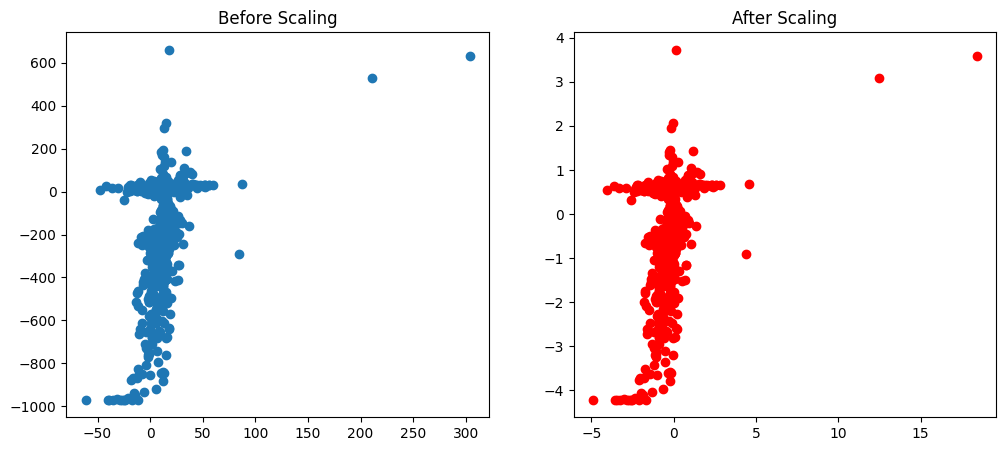

In [ ]:
# Effect of scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['# mean_0_a'], X_train['mean_2_a'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['# mean_0_a'], X_train_scaled['mean_2_a'],color='red')
ax2.set_title("After Scaling")
plt.show()

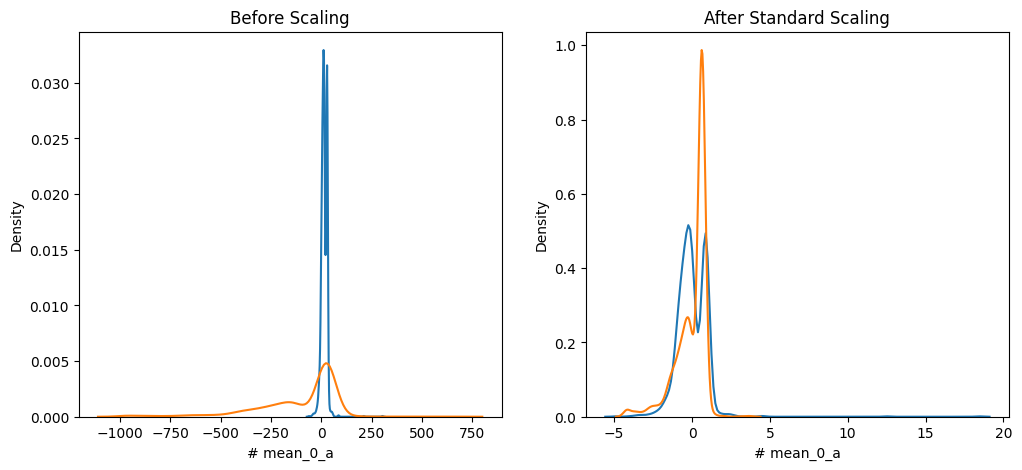

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['# mean_0_a'], ax=ax1)
sns.kdeplot(X_train['mean_2_a'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['# mean_0_a'], ax=ax2)
sns.kdeplot(X_train_scaled['mean_2_a'], ax=ax2)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [ ]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8711943793911007
Scaled 0.8969555035128806


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
RF = RandomForestClassifier()
RF_scaled = RandomForestClassifier()

In [ ]:
RF.fit(X_train,y_train)
RF_scaled.fit(X_train_scaled,y_train)

RandomForestClassifier()

In [ ]:
y_pred = RF.predict(X_test)
y_pred_scaled = RF_scaled.predict(X_test_scaled)

In [ ]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.9718969555035128
Scaled 0.9672131147540983
